In [2]:
from sklearn.datasets import make_regression
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
X,y = make_regression(n_samples=100, n_features=3, n_informative=3, n_targets=1, noise =50)

In [6]:
df = pd.DataFrame({'feature1':X[:,0],'feature2':X[:,1], 'feature3':X[:,2], 'target':y})

In [7]:
df.shape

(100, 4)

In [8]:
df.head()

,feature1,feature2,feature3,target
0,0.216631,-0.367158,-1.474179,7.462944
1,0.483265,-0.683109,-0.705988,150.183163
2,0.120471,-1.303450,1.283937,-50.423810
3,0.057244,0.493134,-1.362651,28.004379
4,-0.901204,-2.729556,-0.042227,-64.910089


In [9]:
X = df.iloc[:,0:3].values
y = df.iloc[:,-1].values

In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=1)

In [12]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[100.46, 18.07, 34.2 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,6.926
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](3,)","[8.81,8.17,7.81]"


In [26]:
# Residual
y_pred = lr.predict(X_test)
residual = y_test - y_pred

## 1. Should form Linear Relationship

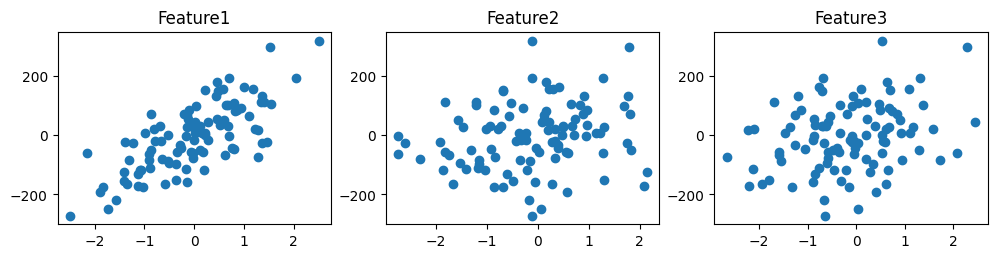

In [18]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3,figsize=(12, 2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title("Feature1")
ax2.scatter(df['feature2'], df['target'])
ax2.set_title("Feature2")
ax3.scatter(df['feature3'], df['target'])
ax3.set_title("Feature3")
plt.show()

In [19]:
# 1st linear 2nd and 3rd not linear

## 2. No Multicolliearity
### Features should be independent to each other

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif =[]

for i in range(X_train.shape[1]):
    vif.append(variance_inflation_factor(X_train, i))

In [23]:
pd.DataFrame({'vif': vif}, index = df.columns[0:3]).T

,feature1,feature2,feature3
vif,1.000502,1.002134,1.001669


<Axes: >

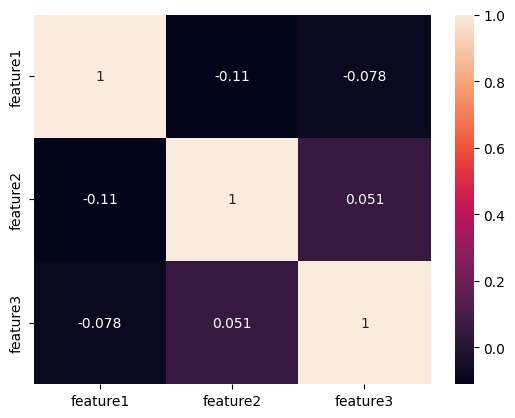

In [25]:
# Another Technique
sns.heatmap(df.iloc[:,0:3].corr(),annot=True)

## 3. Normal Residual
### Minimum error (mean ~ 0)

<Axes: ylabel='Density'>

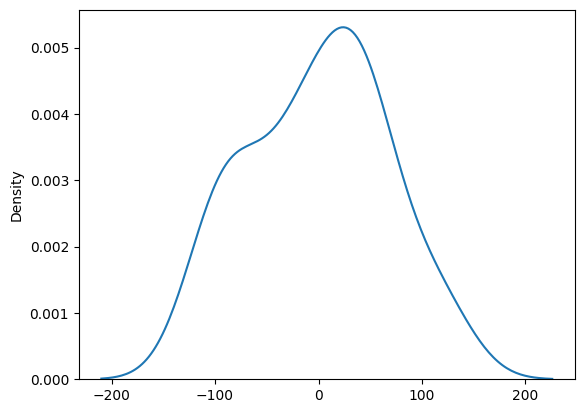

In [27]:
sns.kdeplot(residual)

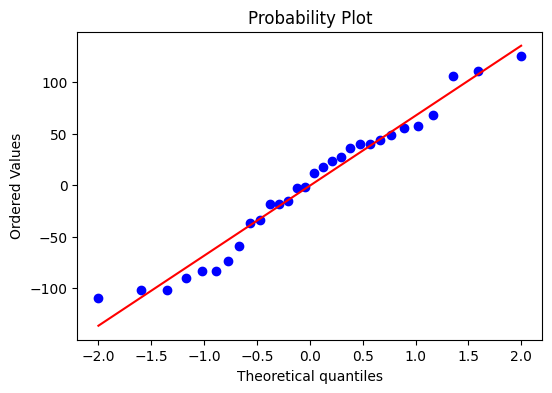

In [29]:
#  QQ Plot

import scipy as sp

fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax,fit=True)

plt.show()

## 4. Homoscedasticity
### Having the same scatter(spread) over the axis

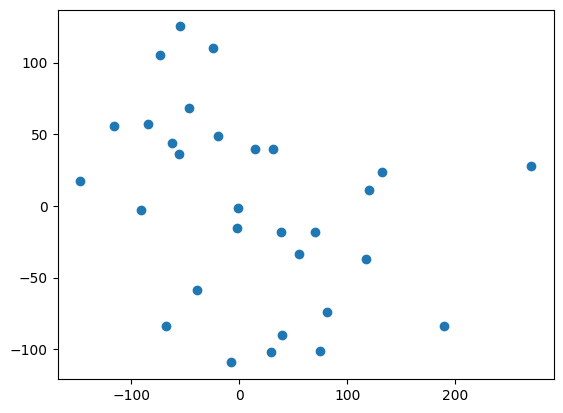

In [30]:
plt.scatter(y_pred,residual)

## 5. Autocorrelation of Residuals
### Should not form the pattern in the graph

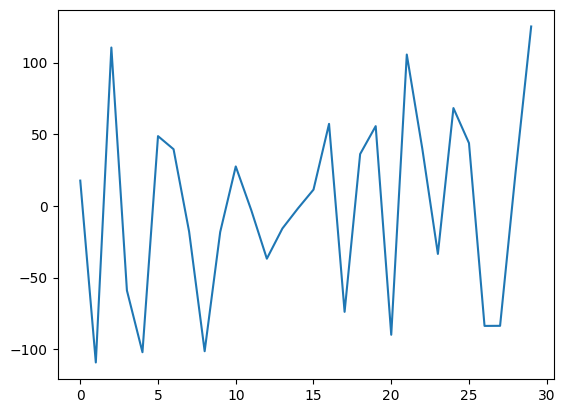

In [31]:
plt.plot(residual)